<a href="https://colab.research.google.com/github/devCat404/AI_Learning/blob/main/Supervised%20Learning/Regression/LinearRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1>Supervised Learning: Regression</h1>

<h3>● Linear Regression</h3>

Linear Regression is one of the simplest supervised learning models for solving regression problems.
It assumes a linear relationship between the input and output, where the input is mapped to the output through learnable weights and a bias.

From a neural network perspective, Linear Regression can be represented as a shallow network consisting of an input layer and an output layer, without any hidden layers.

<br>

<div align="center">

<img src="https://joshuagoings.com/assets/linear.png" width="600">

</div>

<br>

The prediction is given by:

$$
\hat{y} = wx + b
$$

The Mean Squared Error (MSE) is commonly used as the loss function because it penalizes larger residuals more strongly.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
import numpy as np

<h3>● Import Libraries</h3>

The following libraries are imported for implementing and visualizing the Linear Regression model.

- <b>PyTorch</b> is used to build and train the neural network.
- <b>torch.nn</b> provides neural network modules such as <code>nn.Linear</code>.
- <b>torch.nn.functional</b> provides commonly used functions such as loss functions.
- <b>matplotlib.pyplot</b> is used to visualize the training process, such as the change in loss over epochs.
- <b>NumPy</b> is used for numerical operations and data manipulation.

| Library | Purpose |
|---|---|
| <code>torch</code> | Tensor computation and automatic differentiation |
| <code>torch.nn</code> | Building neural network models and layers |
| <code>torch.nn.functional</code> | Functional operations and loss functions |
| <code>matplotlib.pyplot</code> | Visualizing training results and loss |
| <code>numpy</code> | Numerical computation and data manipulation |

In this implementation, <code>torch</code> and <code>torch.nn</code> are mainly used to construct and train the Linear Regression model, while <code>matplotlib</code> is used to visualize how the loss changes during training.

In [ ]:
class LinearRegression(nn.Module):
    def __init__(self, input_size, output_size):
        super(LinearRegression, self).__init__()

        self.input_size = input_size
        self.output_size = output_size

        self.linear = nn.Linear(self.input_size, self.output_size)

    def forward(self, x):
        out = self.linear(x)
        return out

<h3>● Define the Linear Regression Model</h3>

In PyTorch, the Linear Regression model can be implemented as a neural network with an input layer and an output layer, without any hidden layers.

The model learns a weight matrix $\mathbf{W}$ and a bias $\mathbf{b}$, and produces the prediction:

$$
\hat{\mathbf{y}} = \mathbf{xW} + \mathbf{b}
$$

The <code>nn.Linear()</code> layer performs this linear transformation.

<br>

<b>1. Define the model class</b>

<code>LinearRegression</code> inherits from <code>nn.Module</code>, which is the base class for PyTorch neural network models.

<br>

<b>2. Initialize the model</b>

<code>input_size</code> specifies the number of input features, while <code>output_size</code> specifies the number of output values.

<code>self.linear = nn.Linear(input_size, output_size)</code> creates the linear layer containing the learnable weights and bias.

For example, when <code>input_size=1</code> and <code>output_size=1</code>:

$$
\hat{y} = wx + b
$$

<br>

<b>3. Forward propagation</b>

The <code>forward()</code> method defines how the input data passes through the model.

When <code>x</code> is given as input,

$$
x \rightarrow \text{Linear Layer} \rightarrow \hat{y}
$$

and <code>self.linear(x)</code> calculates the predicted output.

<br>

Therefore, the entire model can be summarized as:

$$
\boxed{\hat{y} = wx + b}
$$

In [ ]:
def loss_function(self, y_pred, y_true):
        loss = F.mse_loss(y_pred, y_true)
        return loss

def optimizer_function(self, learning_rate):
        optimizer = torch.optim.SGD(self.parameters(), lr=learning_rate)
        return optimizer

def train():
    model = LinearRegression(1, 1)
    optimizer = optimizer_function(model, 0.01)
    loss_history = []
    for epoch in range(100):
        y_pred = model(x_train)
        loss = loss_function(model, y_pred, y_train)
        loss_history.append(loss.item())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if epoch % 10 == 0 and epoch != 0:
          print(f"Epoch [{epoch}/100], Loss: {loss.item():.6f}")
    return model, loss_history

def learning_curve(loss_history):
    plt.plot(loss_history)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.show()
    return

def predict(model, x_test):
    y_pred = model(x_test)
    return y_pred

def plot_regression(model, x_train, y_train, x_test, y_pred)
    plt.scatter(
        x_train.numpy(),
        y_train.numpy(),
        label='Training data'
    )

    plt.scatter(
        x_test.numpy(),
        y_pred.detach().numpy(),
        label='Predicted data'
    )

    w = model.linear.weight.item()
    b = model.linear.bias.item()

    x_line = torch.linspace(
        x_train.min(),
        x_test.max(),
        100
    )

    y_line = w * x_line + b

    plt.plot(
        x_line.numpy(),
        y_line.detach().numpy(),
        color= 'red',
        label='Regression line'
    )

    plt.xlabel('X')
    plt.ylabel('Y')
    plt.legend()
    plt.show()

<h3>● Loss Function, Optimizer, and Training</h3>

After defining the Linear Regression model, three main components are required to train the model:

1. <b>Loss Function</b> — measures the difference between the predicted value and the true value.
2. <b>Optimizer</b> — updates the model parameters to minimize the loss.
3. <b>Training Loop</b> — repeatedly performs prediction, loss calculation, backpropagation, and parameter updates.

<br>

<b>1. Loss Function</b>

The Mean Squared Error (MSE) is used to measure the difference between the predicted values and the true values.

$$
L = \frac{1}{N}\sum_{i=1}^{N}(\hat{y}_i-y_i)^2
$$

MSE squares the residuals, so larger prediction errors receive a larger penalty.

<br>

<b>2. Optimizer</b>

The optimizer updates the learnable parameters of the model using the gradients calculated through backpropagation.

In this implementation, Stochastic Gradient Descent (SGD) is used.

$$
\theta \leftarrow \theta - \eta \frac{\partial L}{\partial \theta}
$$

where $\theta$ represents the model parameters and $\eta$ is the learning rate.

For Linear Regression, the learnable parameters are the weight $w$ and bias $b$.

$$
w \leftarrow w - \eta\frac{\partial L}{\partial w}
$$

$$
b \leftarrow b - \eta\frac{\partial L}{\partial b}
$$

<br>

<b>3. Training Loop</b>

The model is trained for multiple epochs. In each epoch, four main steps are performed:

$$
\boxed{
\text{Forward Propagation}
\rightarrow
\text{Loss Calculation}
\rightarrow
\text{Backpropagation}
\rightarrow
\text{Parameter Update}
}
$$

<b>① Forward Propagation</b>

The model generates a prediction from the input.

$$
\hat{y} = wx+b
$$

<b>② Loss Calculation</b>

The prediction is compared with the true target using MSE.

$$
L = \text{MSE}(\hat{y},y)
$$

<b>③ Backpropagation</b>

The gradients of the loss with respect to the model parameters are calculated.

$$
\frac{\partial L}{\partial w},
\qquad
\frac{\partial L}{\partial b}
$$

<b>④ Parameter Update</b>

The optimizer uses the calculated gradients to update the weight and bias.

<br>

<b>4. Learning Curve</b>

The loss from each epoch is stored in <code>loss_history</code>.

Plotting the loss history allows us to observe how the model learns over time.

A decreasing loss generally indicates that the model is approaching a better fit to the training data.

<br>

<b>5. Prediction</b>

After training, the learned model can be used to predict new input values.

The trained weight and bias are used to calculate the predicted output:

$$
\hat{y}_{test} = wx_{test}+b
$$

<br>

<b>6. Regression Visualization</b>

The training data, predicted test values, and learned regression line can be visualized together.

The learned regression line is given by:

$$
y_{line}=wx_{line}+b
$$

This allows us to visually compare the original data with the linear relationship learned by the model.

<br>

<b>Overall Training Process</b>

$$
\boxed{
x
\rightarrow
\hat{y}=wx+b
\rightarrow
L=\text{MSE}(\hat{y},y)
\rightarrow
\text{Backpropagation}
\rightarrow
\text{SGD}
\rightarrow
(w,b)\text{ update}
}
$$

Epoch [10/100], Loss: 2.158700
Epoch [20/100], Loss: 0.382270
Epoch [30/100], Loss: 0.204814
Epoch [40/100], Loss: 0.180002
Epoch [50/100], Loss: 0.170097
Epoch [60/100], Loss: 0.161965
Epoch [70/100], Loss: 0.154340
Epoch [80/100], Loss: 0.147085
Epoch [90/100], Loss: 0.140173


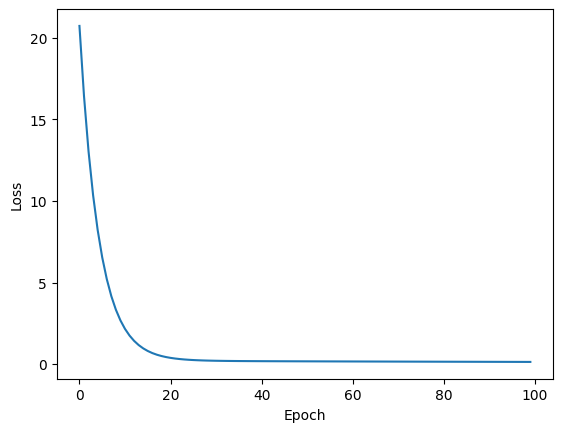

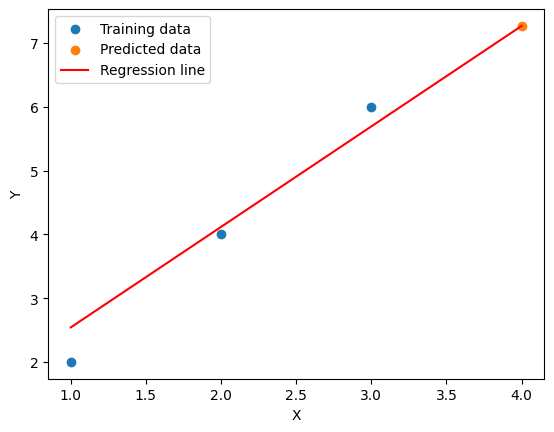

tensor([[7.2669]], grad_fn=<AddmmBackward0>)
OrderedDict({'linear.weight': tensor([[1.5755]]), 'linear.bias': tensor([0.9650])})


In [ ]:
if __name__ == '__main__':
    x_train = torch.tensor([[1.0], [2.0], [3.0]])
    y_train = torch.tensor([[2.0], [4.0], [6.0]])

    x_test = torch.tensor([[4.0]])

    model, loss_history = train()
    learning_curve(loss_history)
    y_pred = predict(model, x_test)

    plot_regression(model, x_train, y_train, x_test, y_pred)
    print(y_pred)
    print(model.state_dict())

<h3>● Prepare Data and Run the Model</h3>

The final section defines the training data and test data, trains the Linear Regression model, evaluates its prediction, and visualizes the learned regression line.

<br>

<b>1. Training Data</b>

The training data consists of three input-output pairs:

$$
x_{train} =
\begin{bmatrix}
1\\
2\\
3
\end{bmatrix}
,\qquad
y_{train} =
\begin{bmatrix}
2\\
4\\
6
\end{bmatrix}
$$

The data follows the relationship:

$$
y=2x
$$

Therefore, the ideal Linear Regression model should learn:

$$
w\approx2,\qquad b\approx0
$$

<br>

<b>2. Test Data</b>

A new input value is provided to evaluate the trained model:

$$
x_{test}=4
$$

Since the underlying relationship is $y=2x$, the expected prediction is:

$$
\hat{y}_{test}\approx8
$$

<br>

<b>3. Model Training</b>

The Linear Regression model is trained using the training data.

During training, the model repeatedly updates $w$ and $b$ to minimize the MSE loss.

$$
\hat{y}=wx+b
$$

$$
L=\frac{1}{N}\sum_{i=1}^{N}(\hat{y}_i-y_i)^2
$$

After training, the learned parameters should be close to:

$$
w\approx2,\qquad b\approx0
$$

<br>

<b>4. Learning Curve</b>

The recorded loss history is plotted to observe how the loss changes over the training epochs.

Ideally, the loss decreases as training progresses.

$$
L_1 > L_2 > L_3 > \cdots
$$

This indicates that the model is gradually approaching the optimal parameters.

<br>

<b>5. Prediction</b>

The trained model is used to predict the output for the unseen test input $x=4$.

$$
\hat{y}=w(4)+b
$$

If the model has learned the underlying relationship successfully:

$$
\hat{y}\approx2(4)+0=8
$$

<br>

<b>6. Regression Visualization</b>

The final plot displays:

<ul>
<li>Training data points</li>
<li>Predicted test data</li>
<li>The learned regression line</li>
</ul>

The regression line represents the relationship learned by the model:

$$
y=wx+b
$$

The closer the learned line is to the training data, the smaller the prediction error becomes.

<br>

<b>7. Inspecting the Learned Parameters</b>

The model's <code>state_dict()</code> is used to inspect the learned parameters.

For this model, it contains:

$$
\text{weight}=w
$$

$$
\text{bias}=b
$$

The final goal of training is therefore to find parameters that minimize the loss:

$$
\boxed{
\min_{w,b}
\frac{1}{N}
\sum_{i=1}^{N}
(wx_i+b-y_i)^2
}
$$

For this simple dataset, the optimal solution is:

$$
\boxed{w=2,\qquad b=0}
$$

and consequently:

$$
\boxed{\hat{y}=2x}
$$

<h3>● Analysis of Training Results</h3>

The training results show that the Linear Regression model successfully learned the overall relationship between $x$ and $y$, but it has not yet converged to the optimal solution.

<br>

<b>1. Loss Decrease</b>

The loss continuously decreases during training:

$$
L_{10}=2.158700
$$

$$
L_{20}=0.382270
$$

$$
L_{30}=0.204814
$$

$$
L_{40}=0.180002
$$

$$
L_{50}=0.170097
$$

$$
L_{60}=0.161965
$$

$$
L_{70}=0.154340
$$

$$
L_{80}=0.147085
$$

$$
L_{90}=0.140173
$$

The rapid decrease during the early epochs indicates that the model is quickly learning the general relationship in the data.

After approximately 30 epochs, however, the decrease becomes much slower. This means that the model is approaching a minimum of the loss function, but has not completely converged.

<br>

<b>2. Learned Parameters</b>

The trained model produced:

$$
w=1.5755
$$

$$
b=0.9650
$$

Therefore, the learned regression equation is approximately:

$$
\boxed{\hat{y}=1.5755x+0.9650}
$$

The ideal relationship in the training data is:

$$
y=2x
$$

Therefore, the learned weight is smaller than the ideal value $w=2$, while the bias is larger than the ideal value $b=0$.

<br>

<b>3. Why Does the Model Not Learn $w=2$ and $b=0$?</b>

The model was trained for only 100 epochs with a learning rate of $0.01$.

Although the loss is decreasing, the parameters have not fully converged to the optimal solution.

The gradient descent process is:

$$
(w,b)
\rightarrow
(w',b')
\rightarrow
(w'',b'')
\rightarrow
\cdots
\rightarrow
(w^*,b^*)
$$

where $(w^*,b^*)$ represents the parameters that minimize the MSE.

Therefore, more training iterations would allow the parameters to move closer to:

$$
w^*=2,\qquad b^*=0
$$

<br>

<b>4. Prediction for $x=4$</b>

The trained model predicts:

$$
\hat{y}=1.5755(4)+0.9650
$$

$$
\hat{y}\approx7.267
$$

which matches the obtained prediction:

$$
\boxed{\hat{y}\approx7.2669}
$$

The true value based on the underlying relationship $y=2x$ is:

$$
y=2(4)=8
$$

Therefore, the prediction error is approximately:

$$
7.2669-8=-0.7331
$$

and the absolute error is:

$$
|\hat{y}-y|\approx0.7331
$$

<br>

<b>5. Overall Interpretation</b>

The model is learning correctly because:

<ul>
<li>The loss decreases consistently during training.</li>
<li>The learned parameters produce a reasonable linear relationship.</li>
<li>The prediction for $x=4$ is reasonably close to the expected value of $8$.</li>
</ul>

However, the model has not fully converged because:

$$
w=1.5755\neq2
$$

and

$$
b=0.9650\neq0
$$

Therefore, increasing the number of epochs or adjusting the learning rate would allow us to investigate whether the model can converge closer to the optimal solution.

<br>

<b>Conclusion</b>

The experiment demonstrates the basic mechanism of gradient-based Linear Regression:

$$
\boxed{
\text{Initial }(w,b)
\rightarrow
\text{Prediction}
\rightarrow
\text{MSE}
\rightarrow
\text{Gradient}
\rightarrow
\text{Parameter Update}
\rightarrow
\text{Lower Loss}
}
$$

In this experiment, the model is moving toward the optimal solution $\boxed{w=2,\ b=0}$, but 100 epochs with a learning rate of $0.01$ were not sufficient for complete convergence.